In [21]:
# ===== 段0：通用准备（建议先执行一次） =====
import sys
from pathlib import Path

# 自动向上查找项目根目录（包含 factors/ 和 strategy/）
cwd = Path.cwd().resolve()
project_root = cwd
for p in [cwd] + list(cwd.parents):
    if (p / "factors").exists() and (p / "strategy").exists():
        project_root = p
        break

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("Using project root:", project_root)

Using project root: /Users/wenglongao/work_repo/lionet


In [22]:
# ===== 段1：使用 BackTester 直接回测 demo_strategy.py 的同一因子 =====
from factors.backtest import BackTester

# 与 demo_strategy.py 保持一致
VERSION = "20260330_gp_test"
FACTOR_NAME = "fac_gp_0002"
INSTRUMENT_ID = "C0"
START_TIME = "20250101"
END_TIME = "20251231"

bt = BackTester(
    fc_name_list=[FACTOR_NAME],
    version=VERSION,
    instrument_type="futures_continuous_contract",
    instrument_id_list=[INSTRUMENT_ID],
    fc_freq="1d",
    data=None,  # 走数据库加载行情 + 因子公式
    start_time=START_TIME,
    end_time=END_TIME,
    portfolio_adjust_method="1D",
    interest_method="simple",
    risk_free_rate=False,
    calculate_baseline=True,
    apply_weighted_price=True,
    apply_rolling_norm=True,
    n_jobs=5,
)

bt.backtest()

print("BackTester performance_summary (tail):")
display(bt.performance_summary.tail(10))

# 可视化（与 backtest.py 的绘图接口一致）
bt.plot_nav(
    fc_name=FACTOR_NAME,
    instrument_id_list=INSTRUMENT_ID,
    show_baseline=True,
)

BrokenProcessPool: A task has failed to un-serialize. Please ensure that the arguments of the function are all picklable.

In [20]:
# ===== 段2：直接实现 demo_strategy.py =====
from strategy.strategy import Strategy

strategy = Strategy(
    database="factors",
    collection="genetic_programming",
    version="20260330_gp_test",
    factor_name="fac_gp_0023",
    instrument_id="C0",
    start_time="20250101",
    end_time="20251231",
    initial_capital=100000000,
    margin_rate=0.1,
    fee_per_lot=2.0,
    slippage=1.0,
)

detail = strategy.backtest()
print(detail[["time", "factor_value", "position_lots", "equity", "nav"]].tail(10).to_string(index=False))
strategy.plot_nav(show_baseline=True)

# 你后续可直接使用这两个对象：
# - bt: BackTester 对象
# - strategy: Strategy 对象
print("bt object:", type(bt))
print("strategy object:", type(strategy))

ValueError: No factor record found in factors.genetic_programming for version=20260323_gp_test, factor_name=fac_gp_0023.

In [10]:
bt.performance_detail['open'].shift(1)

0               NaN
1       1911.000000
2       1920.000000
3       1918.000000
4       1914.000000
           ...     
1207    2006.950862
1208    2016.148621
1209    2029.025482
1210    2030.865034
1211    2054.779205
Name: open, Length: 1212, dtype: float64

In [15]:
int(1.9)

1

In [9]:
bt.performance_detail.columns

Index(['time', 'instrument_id', 'open', 'high', 'low', 'close', 'volume',
       'position', 'cur_weighted_factor', 'is_rollover', 'settle', 'symbol',
       'weighted_factor', 'factor_value', 'future_ret', 'daily_gross_ret',
       'daily_net_ret', 'daily_turnover', 'daily_gross_nav', 'daily_net_nav',
       'factor_name', 'daily_gross_ret_baseline_long',
       'daily_gross_ret_baseline_short', 'daily_net_ret_baseline_long',
       'daily_net_ret_baseline_short', 'daily_gross_nav_baseline_long',
       'daily_gross_nav_baseline_short', 'daily_net_nav_baseline_long',
       'daily_net_nav_baseline_short'],
      dtype='object')

<Axes: >

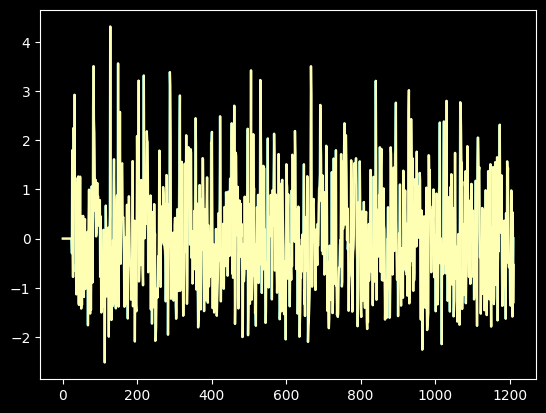

In [4]:
bt.performance_detail['factor_value'].plot()
strategy.performance_detail['factor_value'].plot()

In [12]:
strategy.performance_detail['factor_value']

0       0.000000
1       0.000000
2       0.000000
3       0.000000
4      -0.390488
          ...   
1207   -0.887920
1208   -0.032318
1209   -0.809714
1210   -0.513158
1211   -0.278682
Name: factor_value, Length: 1212, dtype: float64

In [8]:
strategy.performance_summary

,Gross Return,Net Return,Gross Volatility,Net Volatility,Gross Sharpe,Net Sharpe,Gross Sortino,Net Sortino,Gross MaxDD,Net MaxDD,...,Net MaxDD (With Baseline),Gross Calmar (With Baseline),Net Calmar (With Baseline),Gross Win Rate (With Baseline),Net Win Rate (With Baseline),Turnover (With Baseline),Factor Name,Factor Freq,Fee,Instrument ID
year,,,,,,,,,,,,,,,,,,,,,
2020,0.181992,0.139423,0.176860,0.176358,1.029017,0.790572,2.366061,1.815120,0.087851,0.098274,...,"0.098274(0.054656,0.320944)","1.02902(2.8807,-2.8807)","0.790572(2.87908,-2.88232)","0.427984(0.518519,0.366255)","0.407407(0.518519,0.366255)","0.844619(0.00411523,0.00411523)",fac_gp_0023,1d,0.0002,C0
2021,0.098125,0.055228,0.128333,0.128689,0.764617,0.429156,1.019151,0.577378,0.073155,0.078548,...,"0.078548(0.134133,0.120324)","0.764617(0.036411,-0.036411)","0.429156(0.036411,-0.036411)","0.510288(0.497942,0.485597)","0.493827(0.497942,0.485597)","0.851149(0,0)",fac_gp_0023,1d,0.0002,C0
2022,0.099466,0.056150,0.136121,0.136217,0.730715,0.412210,1.009915,0.574237,0.109435,0.114739,...,"0.114739(0.154824,0.129777)","0.730715(0.522272,-0.522272)","0.41221(0.522272,-0.522272)","0.483471(0.516529,0.466942)","0.466942(0.516529,0.466942)","0.859441(0,0)",fac_gp_0023,1d,0.0002,C0
2023,0.265398,0.224249,0.126160,0.125681,2.103660,1.784273,3.704817,3.138811,0.065461,0.069404,...,"0.0694041(0.178105,0.102901)","2.10366(-1.35978,1.35978)","1.78427(-1.35978,1.35978)","0.524793(0.479339,0.504132)","0.504132(0.479339,0.504132)","0.816436(0,0)",fac_gp_0023,1d,0.0002,C0
2024,0.211057,0.165648,0.119081,0.119162,1.772378,1.390110,2.642837,2.106064,0.057845,0.071152,...,"0.0711523(0.172457,0.0792815)","1.77238(-0.617818,0.617818)","1.39011(-0.617818,0.617818)","0.508264(0.42562,0.53719)","0.495868(0.42562,0.53719)","0.900966(0,0)",fac_gp_0023,1d,0.0002,C0
all,0.171156,0.128089,0.138692,0.138577,1.234072,0.924316,1.999443,1.507164,0.109435,0.114739,...,"0.114739(0.314679,0.411896)","1.23407(0.351964,-0.351964)","0.924316(0.351633,-0.352295)","0.490924(0.487624,0.471947)","0.473597(0.487624,0.471947)","0.854511(0.000825083,0.000825083)",fac_gp_0023,1d,0.0002,C0


In [7]:
bt.performance_summary

,Gross Return,Net Return,Gross Volatility,Net Volatility,Gross Sharpe,Net Sharpe,Gross Sortino,Net Sortino,Gross MaxDD,Net MaxDD,...,Net MaxDD (With Baseline),Gross Calmar (With Baseline),Net Calmar (With Baseline),Gross Win Rate (With Baseline),Net Win Rate (With Baseline),Turnover (With Baseline),Factor Name,Factor Freq,Fee,Instrument ID
year,,,,,,,,,,,,,,,,,,,,,
2020,0.064443,0.021403,0.152511,0.151924,0.422547,0.140878,0.841279,0.279724,0.094786,0.106719,...,"0.106719(0.0487138,0.291679)","0.422547(2.75956,-2.75956)","0.140878(2.75777,-2.76134)","0.427984(0.563786,0.411523)","0.407407(0.563786,0.411523)","0.853975(0.00411523,0.00411523)",fac_gp_0023,1d,0.0002,C0
2021,0.065306,0.022014,0.127543,0.127862,0.512032,0.172169,0.682767,0.231268,0.073163,0.078556,...,"0.0785557(0.148106,0.111244)","0.512032(0.0391665,-0.0391665)","0.172169(0.0391665,-0.0391665)","0.506173(0.497942,0.489712)","0.489712(0.497942,0.489712)","0.858973(0,0)",fac_gp_0023,1d,0.0002,C0
2022,0.118720,0.074106,0.136177,0.136358,0.871812,0.543468,1.198809,0.753202,0.107181,0.112433,...,"0.112433(0.15486,0.122289)","0.871812(0.267796,-0.267796)","0.543468(0.267796,-0.267796)","0.487603(0.516529,0.466942)","0.471074(0.516529,0.466942)","0.885205(0,0)",fac_gp_0023,1d,0.0002,C0
2023,0.222048,0.181848,0.119015,0.118571,1.865720,1.533664,3.158879,2.609283,0.052975,0.056849,...,"0.0568485(0.146334,0.115003)","1.86572(-1.08921,1.08921)","1.53366(-1.08921,1.08921)","0.516529(0.483471,0.491736)","0.491736(0.483471,0.491736)","0.797622(0,0)",fac_gp_0023,1d,0.0002,C0
2024,0.234514,0.189632,0.116911,0.117077,2.005910,1.619724,2.959318,2.436472,0.048225,0.061624,...,"0.0616243(0.176943,0.0575955)","2.00591(-1.37663,1.37663)","1.61972(-1.37663,1.37663)","0.520661(0.417355,0.541322)","0.508264(0.417355,0.541322)","0.890509(0,0)",fac_gp_0023,1d,0.0002,C0
all,0.140881,0.097675,0.130958,0.130871,1.075768,0.746343,1.651728,1.154581,0.111792,0.141632,...,"0.141632(0.30725,0.362493)","1.07577(0.176769,-0.176769)","0.746343(0.176421,-0.177116)","0.491749(0.495875,0.480198)","0.473597(0.495875,0.480198)","0.857255(0.000825083,0.000825083)",fac_gp_0023,1d,0.0002,C0


In [8]:
bt.performance_dc['C0']

{'fac_gp_0023': {'gross_annualized_ret':       fac_gp_0023
  year             
  2020     0.064443
  2021     0.065306
  2022     0.118720
  2023     0.222048
  2024     0.234514
  all      0.140881,
  'gross_annualized_volatility':       fac_gp_0023
  year             
  2020     0.152511
  2021     0.127543
  2022     0.136177
  2023     0.119015
  2024     0.116911
  all      0.130958,
  'gross_annualized_sharpe':       fac_gp_0023
  year             
  2020     0.422547
  2021     0.512032
  2022     0.871812
  2023     1.865720
  2024     2.005910
  all      1.075768,
  'gross_annualized_sortino':       fac_gp_0023
  year             
  2020     0.841279
  2021     0.682767
  2022     1.198809
  2023     3.158879
  2024     2.959318
  all      1.651728,
  'gross_annualized_max_drawdown':       fac_gp_0023
  year             
  2020     0.094786
  2021     0.073163
  2022     0.107181
  2023     0.052975
  2024     0.048225
  all      0.111792,
  'gross_drawdown':       fac_gp_0023